### Oppgave 1: Skytemetode for randverdiproblem

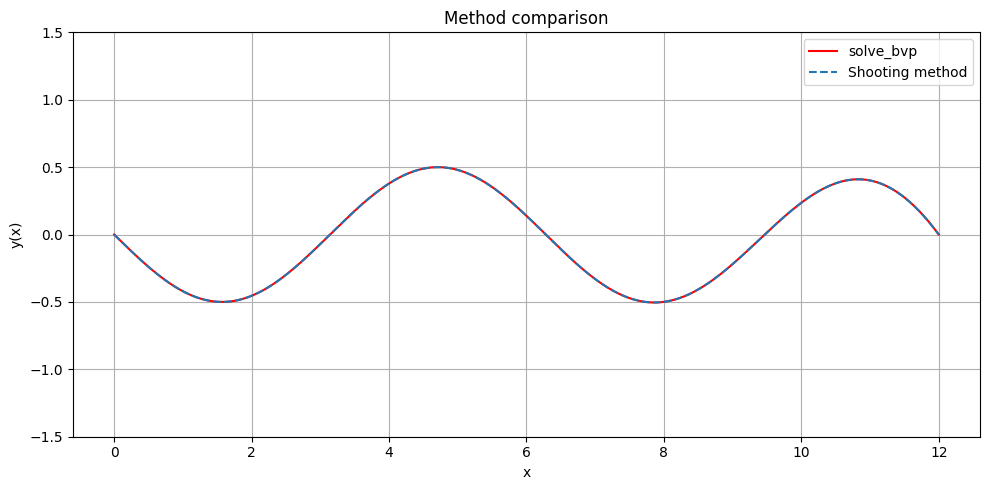

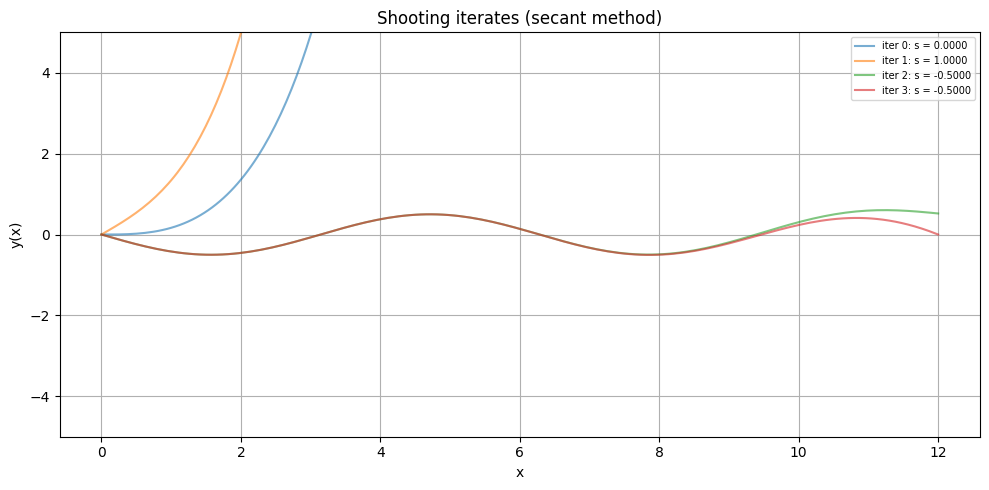

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp


def diff_system_1(x: float, y: np.ndarray) -> np.ndarray:
    return np.array([y[1], -4.0 * np.sin(2.0 * x)])


def diff_system_2(x: float, y: np.ndarray) -> np.ndarray:
    return np.array([y[1], y[0] + np.sin(x)])


def bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
    """Boundary conditions: y(x0) = ya, y(xend) = yb."""
    return np.array([ya[0], yb[0]])


def ivp_solver(
    f, y: np.ndarray, params: dict
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    x = params["x0"]
    xend = params["xend"]
    h = params["h0"]
    tol = params["tol"]
    alpha = params["alpha"]

    Xa = [x]
    Ya = [y.copy()]
    Ha = [h]

    k1 = f(x, y)

    while xend - x > 0:
        h = min(h, xend - x)

        k2 = f(x + 0.5 * h,  y + 0.5 * h * k1)
        k3 = f(x + 0.75 * h, y + 0.75 * h * k2)
        y_new = y + (h / 9.0) * (2 * k1 + 3 * k2 + 4 * k3)

        k4 = f(x + h, y_new)
        z_new = y + (h / 24.0) * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4)

        est = np.linalg.norm(y_new - z_new)

        if est < tol:
            x = x + h
            y = y_new
            k1 = k4
            Xa.append(x)
            Ya.append(y.copy())
            Ha.append(h)

        if est == 0:
            h = 2.0 * h
        else:
            h = alpha * h * (tol / est) ** (1 / 3)

    return np.array(Xa), np.array(Ya), np.array(Ha)



def shoot(diff_system, s: float, params: dict) -> tuple[np.ndarray, np.ndarray]:
    """Solve IVP with initial slope s and return (X, Y)."""
    y0 = np.array([params["ya"], s])
    X, Y, _ = ivp_solver(diff_system, y0, params)
    return X, Y


def F(diff_system, s: float, params: dict) -> float:
    """Shooting residual: y(xend) - yb."""
    _, Y = shoot(diff_system, s, params)
    return Y[-1, 0] - params["yb"]



def secant_method(diff_system, z0: float, z1: float, params: dict) -> tuple[float, list]:
    """
    Find s such that F(s) = 0 using the secant method.
    Returns (s_solution, history) where history is a list of [s, F(s)] pairs.
    """
    history = []

    z_prev, z_curr = z0, z1
    g_prev = F(diff_system, z_prev, params)
    g_curr = F(diff_system, z_curr, params)

    history.append([z_prev, g_prev])
    history.append([z_curr, g_curr])

    while abs(z_curr - z_prev) >= params["tol"]:
        z_new  = (z_prev * g_curr - z_curr * g_prev) / (g_curr - g_prev)
        g_new  = F(diff_system, z_new, params)
        history.append([z_new, g_new])

        z_prev, g_prev = z_curr, g_curr
        z_curr, g_curr = z_new, g_new

    return z_curr, history


def worse_method(diff_system, params: dict) -> tuple[np.ndarray, np.ndarray, list]:
    """Shooting method with secant method for finding roots"""
    s_sol, history = secant_method(diff_system, 0.0, 1.0, params)
    X, Y = shoot(diff_system, s_sol, params)
    return X, Y[:, 0], history


def better_method(diff_system, params: dict) -> tuple[np.ndarray, np.ndarray]:
    """scipy.integrate.solve_bvp"""
    x0 = np.linspace(params["x0"], params["xend"], 50)
    y0 = np.zeros((2, x0.size))

    sol = solve_bvp(diff_system, bc, x0, y0)

    X = np.linspace(params["x0"], params["xend"], 500)
    Y = sol.sol(X)
    return X, Y[0]



def plot_solution(ax: plt.Axes, X: np.ndarray, Y: np.ndarray, label: str = "", **plot_kwargs) -> None:
    """Plot a single BVP solution on the given axes."""

    ax.plot(X, Y, label=label, **plot_kwargs)
    ax.set_xlabel("x")
    ax.set_ylabel("y(x)")
    ax.grid(True)
    if label:
        ax.legend()


def plot_shooting_iterations(ax: plt.Axes, diff_system, history: list, params: dict) -> None:
    """Plot each shooting iterate from the secant-method history."""
    for i, (s, _) in enumerate(history):
        X, Y = shoot(diff_system, s, params)
        ax.plot(X, Y[:, 0], alpha=0.6, label=f"iter {i}: s = {s:.4f}")

    ax.set_xlabel("x")
    ax.set_ylabel("y(x)")
    ax.set_title("Shooting iterates (secant method)")
    ax.grid(True)
    ax.legend(fontsize=7)


params = {
    "x0": 0.0,
    "xend": 12.0,
    "ya": 0.0, 
    "yb": 0.0,
    "h0": 1e-3,
    "tol": 1e-5,
    "alpha": 0.8,
}

diff_system = diff_system_2

# Solve with both methods
X_bad,  Y_bad, history = worse_method(diff_system, params)
X_good, Y_good = better_method(diff_system, params)

# Method comparison 
fig1, ax1 = plt.subplots(figsize=(10, 5))
plot_solution(ax1, X_good, Y_good, label="solve_bvp", color="red")
plot_solution(ax1, X_bad,  Y_bad, label="Shooting method", linestyle="--")
ax1.set_title("Method comparison")
ax1.set_ylim(-1.5, 1.5)
plt.tight_layout()

# Shooting iterations
fig2, ax2 = plt.subplots(figsize=(10, 5))
plot_shooting_iterations(ax2, diff_system, history, params)
ax2.set_ylim(-5, 5)
plt.tight_layout()

plt.show()

### Oppgave 2 : Usadel my G

Mækker hjelpefunksjoner som brukes videre i oppgave 2h og utover.

In [ ]:
# Parameters
delta = 0.01
zeta = 3.0
l = 1.0
m = 101

# Task 2a
def M_transform(M: np.ndarray) -> np.ndarray:
    M = M.copy()

    real_arr = np.real(M).flatten()
    imag_arr = np.imag(M).flatten()

    return np.concatenate([real_arr, imag_arr])


def M_transform_inverse(m: np.ndarray) -> np.ndarray:
    m = m.copy()

    M = m[:4] + 1j * m[4:]
    M = M.reshape(2, 2)

    return M

# Task 2b
def real_transform(m1: np.ndarray, m2: np.ndarray, m3: np.ndarray, m4: np.ndarray) -> np.ndarray:
    return np.concatenate([m1, m2, m3, m4])


def real_tranform_inverse(v: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    m_len = len(v) // 4

    m1 = v[:m_len]
    m2 = v[m_len : 2*m_len]
    m3 = v[2*m_len : 3*m_len]
    m4 = v[3*m_len:]

    return m1, m2, m3, m4

# Task 2c
def matrices_to_v(gamma: np.ndarray, gamma_thilde: np.ndarray, omega: np.ndarray, omega_thilde: np.ndarray) -> np.ndarray:
    return real_transform(
        M_transform(gamma),
        M_transform(gamma_thilde),
        M_transform(omega),
        M_transform(omega_thilde),
    )


def v_to_matrices(v: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    gamma, gamma_thilde, omega, omega_thilde = real_tranform_inverse(v)

    return gamma, gamma_thilde, omega, omega_thilde


# Task 2d
def N_fun(gamma: np.ndarray, gamma_tilde: np.ndarray, tilde: bool) -> np.ndarray:
    I = np.eye(2) # identity matrix

    if tilde:
        return np.linalg.inv(I - gamma_tilde @ gamma)
    else:
        return np.linalg.inv(I - gamma @ gamma_tilde)


def v_derivative(v: np.ndarray, eps: float) -> np.ndarray:
    """Returns dv/dx given v and epsilon."""
     
    gamma, gamma_tilde, omega, omega_tilde = v_to_matrices(v)

    gamma = M_transform_inverse(gamma)
    gamma_tilde = M_transform_inverse(gamma_tilde)
    omega = M_transform_inverse(omega)
    omega_tilde = M_transform_inverse(omega_tilde)

    N = N_fun(gamma, gamma_tilde, False)
    N_tilde = N_fun(gamma, gamma_tilde, True)

    dgamma_dx = omega
    dgamma_tilde_dx = omega_tilde
    
    domega_dx = (
        -2j * (eps + 1j * delta) * gamma
        - 2 * omega @ N_tilde @ gamma_tilde @ omega
    )

    domega_tilde_dx = (
        -2j * (eps + 1j * delta) * gamma_tilde
        - 2 * omega_tilde @ N @ gamma @ omega_tilde
    )

    return matrices_to_v(dgamma_dx, dgamma_tilde_dx, domega_dx, domega_tilde_dx)

# Task 2e
def make_diff_system(eps: float):
    def diff_system(x, vec):
        result = np.zeros_like(vec)
        for i in range(len(x)):
            result[:, i] = v_derivative(vec[:, i], eps)

        return result
    return diff_system

# Task 2f
def make_bc(eps: float):
    def bc(v_left: np.ndarray, v_right: np.ndarray) -> np.ndarray:

        l_gamma, l_gamma_tilde, l_omega, l_omega_tilde = v_to_matrices(v_left)
        r_gamma, r_gamma_tilde, r_omega, r_omega_tilde = v_to_matrices(v_right)

        l_gamma = M_transform_inverse(l_gamma)
        l_gamma_tilde = M_transform_inverse(l_gamma_tilde)
        l_omega = M_transform_inverse(l_omega)
        l_omega_tilde = M_transform_inverse(l_omega_tilde)

        r_gamma = M_transform_inverse(r_gamma)
        r_gamma_tilde = M_transform_inverse(r_gamma_tilde)
        r_omega = M_transform_inverse(r_omega)
        r_omega_tilde = M_transform_inverse(r_omega_tilde)

        # Calculating left-hand side bc
        l_bc_1 = l_omega - 1/(zeta*l) * l_gamma 
        l_bc_2 = l_omega_tilde - 1/(zeta*l) * l_gamma_tilde 

        # Calculating right-hand side bc
        r_bc_1 = r_omega - 1/(zeta*l) * r_gamma 
        r_bc_2 = r_omega_tilde - 1/(zeta*l) * r_gamma_tilde 

        return np.concatenate([
            M_transform(l_bc_1),
            M_transform(l_bc_2),
            M_transform(r_bc_1),
            M_transform(r_bc_2),
        ])
    
    return bc

### Oppgave 2g: BVP-løsning for $\gamma_L = \gamma_R = \tilde{\gamma}_L = \tilde{\gamma}_R = 0$

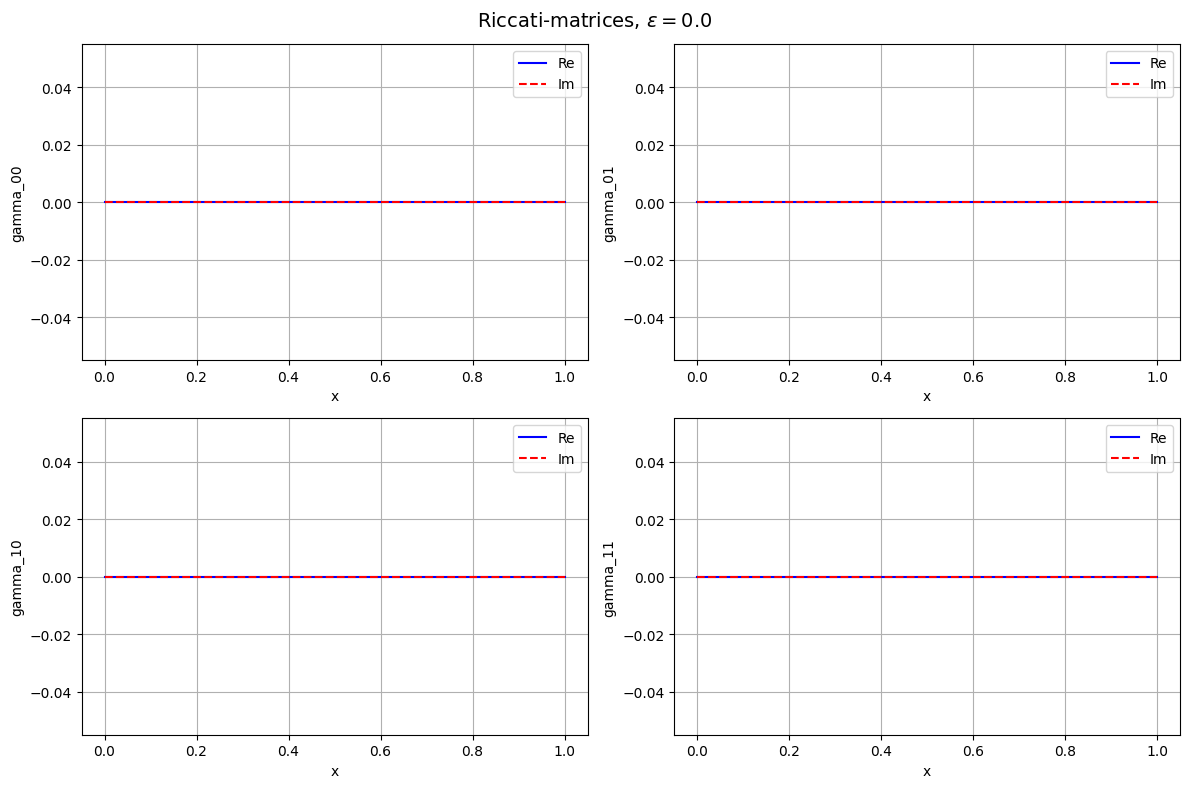

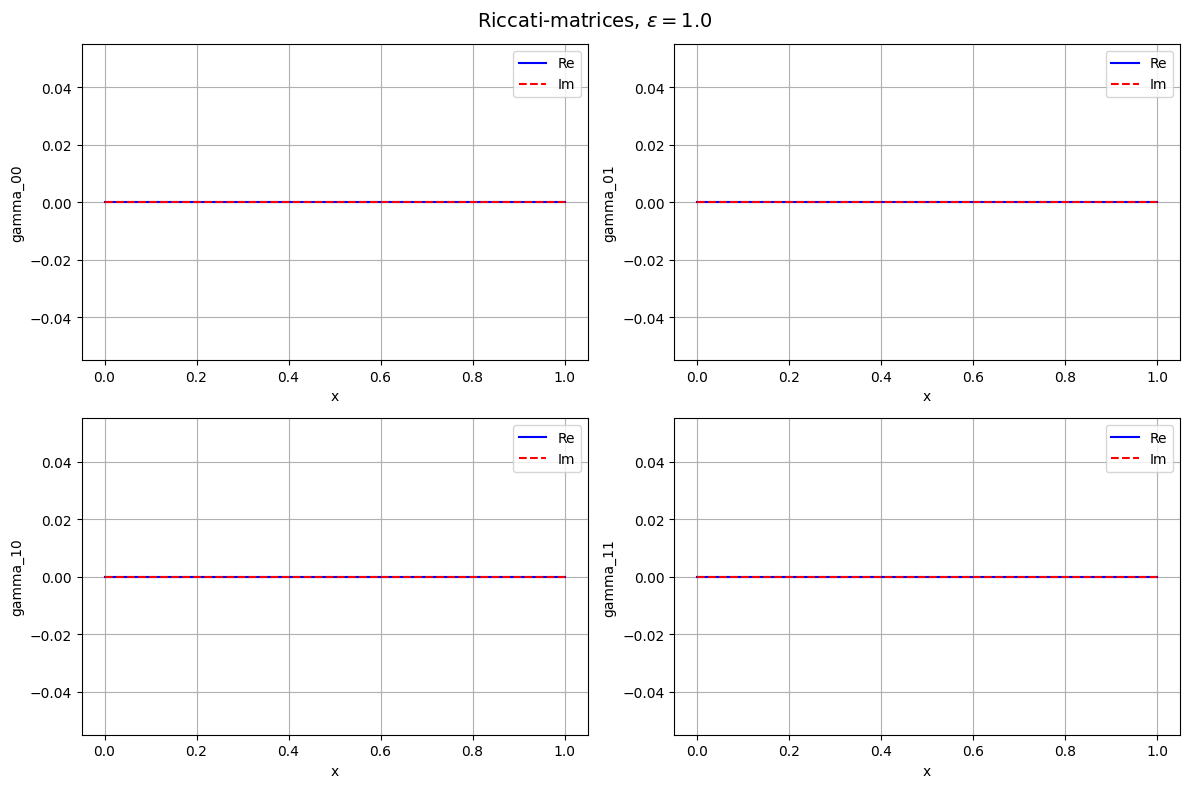

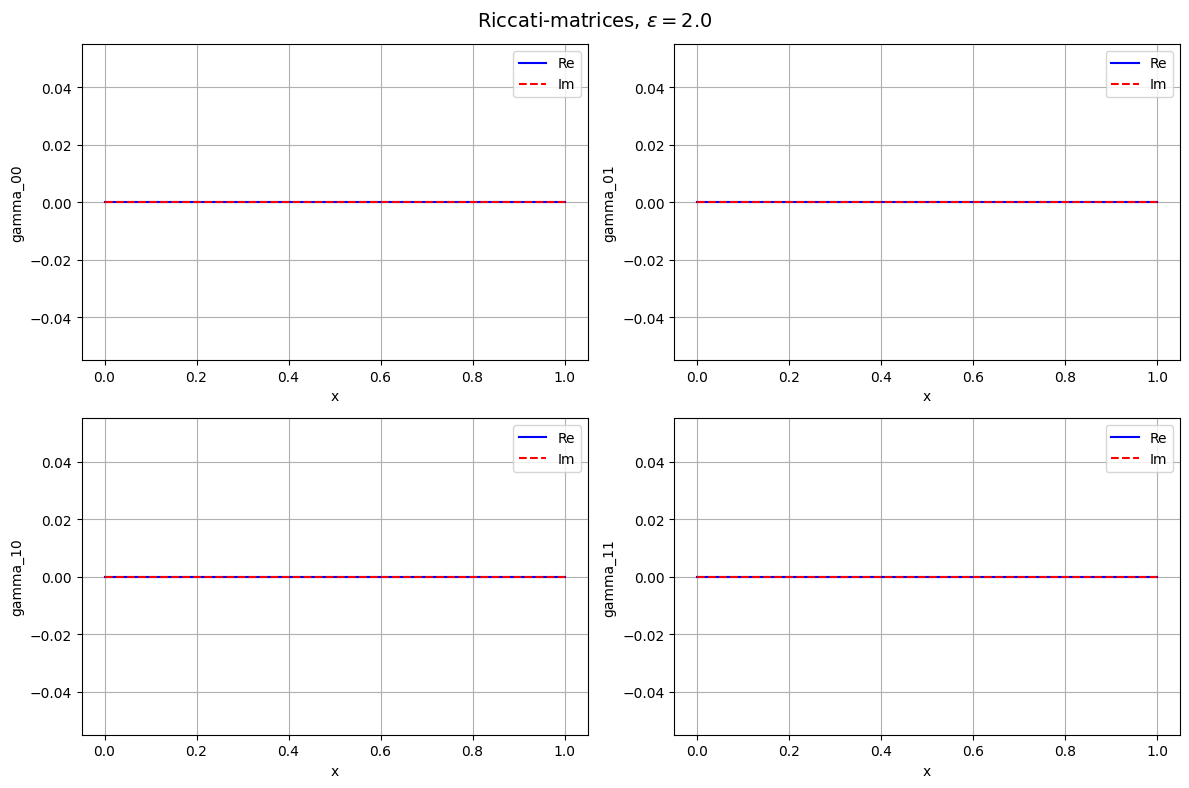

In [ ]:
# Task 2g
# Plot the solutions of the BVP
for eps in [0.0, 1.0, 2.0]:

    x = np.linspace(0, l, m)
    y = np.zeros((32, m))

    sol = solve_bvp(make_diff_system(eps), make_bc(eps), x, y)

    x_plot = np.linspace(0, l, 200)
    v_plot = sol.sol(x_plot)

    # solution matrix
    gamma_11 = v_plot[0] + 1j * v_plot[4]
    gamma_12 = v_plot[1] + 1j * v_plot[5]
    gamma_21 = v_plot[2] + 1j * v_plot[6]
    gamma_22 = v_plot[3] + 1j * v_plot[7]

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(r'Riccati-matrices, $\epsilon =$'+ f'{eps}', fontsize=14)

    for i, comp in enumerate([gamma_11, gamma_12, gamma_21, gamma_22]):

        axs[i // 2][i % 2].plot(x_plot, np.real(comp), 'b-', label='Re')
        axs[i // 2][i % 2].plot(x_plot, np.imag(comp), 'r--', label='Im')
        axs[i // 2][i % 2].set_xlabel('x')
        axs[i // 2][i % 2].set_ylabel(f'gamma_{i // 2}{i % 2}')
        axs[i // 2][i % 2].legend()
        axs[i // 2][i % 2].grid(True)

    plt.tight_layout()
    plt.show()


### Oppgave 2h-2i: Green-funksjon, DOS og mer generelle randbetingelser

In [ ]:
delta = 0.01
zeta = 3.0
l = 1.0
m = 101


# Task 2h
def greens_fun(gamma: np.ndarray, gamma_tilde: np.ndarray) -> np.ndarray:

    I = np.eye(2) # identity matrix

    N = N_fun(gamma, gamma_tilde, False) 
    N_tilde = N_fun(gamma, gamma_tilde, True)

    g_hat = np.block([[2*N - I, 2*N @ gamma], [-2*N_tilde @ gamma_tilde, -2*N_tilde + I]])

    return g_hat

 
def DOS_fun(gamma: np.ndarray, gamma_tilde: np.ndarray) -> np.ndarray:
    I = np.eye(2) # identity matrix
    M_0 = np.zeros((2, 2)) # zero matrix

    rho_hat = np.block([[I, M_0], [M_0, -I]])
    g_hat = greens_fun(gamma, gamma_tilde)

    DOS_normalized = np.real(np.trace(rho_hat @ g_hat)) / 4

    return DOS_normalized


M_0 = np.zeros((2, 2)) # zero matrix

# Asume gamma = gamma_thilde = 0
gamma = M_0.copy()
gamma_tilde = M_0.copy()
 
DOS_normalized = DOS_fun(gamma, gamma_tilde) # = 1 (konst)

# TODO: Plot

# Task 2i
def theta_fun(sigma: float, eps: float, delta: float):
    return np.atanh(sigma / (eps + 1j * delta))


def gamma_boundary(phi: float, tilde: bool, eps: float, delta: float) -> np.ndarray:
    theta_m = np.arctanh(-1.0 / (eps + 1j * delta))
    theta_p = np.arctanh( 1.0 / (eps + 1j * delta))

    s_m = np.sinh(theta_m)
    s_p = np.sinh(theta_p)
    c_m = np.cosh(theta_m)
    c_p = np.cosh(theta_p)

    if tilde:
        return np.array([[0, s_m/(1 + c_m)], [s_p/(1 + c_p), 0]]) * np.exp(-1j * phi)
    else:
        return np.array([[0, s_p/(1 + c_p)], [s_m/(1 + c_m), 0]]) * np.exp(1j * phi)


def make_bc(eps: float, l: float, phi_L: float = 0.0, phi_R: float = 0.0):
    def bc(v_left, v_right):
        l_gamma, l_gamma_tilde, l_omega, l_omega_tilde = [M_transform_inverse(x) for x in v_to_matrices(v_left)]
        r_gamma, r_gamma_tilde, r_omega, r_omega_tilde = [M_transform_inverse(x) for x in v_to_matrices(v_right)]

        I = np.eye(2) # identity matrix

        gamma_L = gamma_boundary(phi_L, False, eps, delta)
        gamma_tilde_L = gamma_boundary(phi_L, True,  eps, delta)
        gamma_R = gamma_boundary(phi_R, False, eps, delta)
        gamma_tilde_R = gamma_boundary(phi_R, True,  eps, delta)

        N_L = N_fun(gamma_L, gamma_tilde_L, False)
        N_tilde_L = N_fun(gamma_L, gamma_tilde_L, True)
        N_R = N_fun(gamma_R, gamma_tilde_R, False)
        N_tilde_R = N_fun(gamma_R, gamma_tilde_R, True)

        l_bc_1 = l_omega + 1/(zeta*l) * (I - l_gamma @ gamma_tilde_L) @ N_L @ (gamma_L - l_gamma)
        l_bc_2 = l_omega_tilde + 1/(zeta*l) * (I - l_gamma_tilde @ gamma_L) @ N_tilde_L @ (gamma_tilde_L - l_gamma_tilde)

        r_bc_1 = r_omega - 1/(zeta*l) * (I - r_gamma @ gamma_tilde_R) @ N_R @ (gamma_R - r_gamma)
        r_bc_2 = r_omega_tilde - 1/(zeta*l) * (I - r_gamma_tilde @ gamma_R) @ N_tilde_R @ (gamma_tilde_R - r_gamma_tilde)

        return np.concatenate([
            M_transform(l_bc_1), M_transform(l_bc_2),
            M_transform(r_bc_1), M_transform(r_bc_2),
        ])
    return bc

### Oppgave 2j: DOS som funksjon av posisjon for konst energi

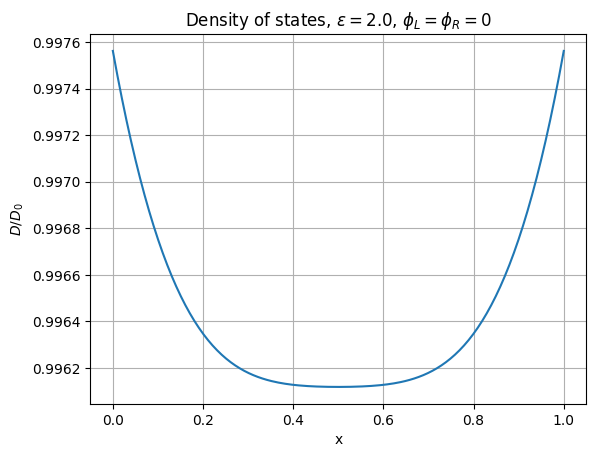

In [ ]:
# Task 2j
# Plot the solutions of the BVP for eps = 2.0
eps = 2.0
x = np.linspace(0, l, m)
y = np.zeros((32, m))

sol = solve_bvp(make_diff_system(eps), make_bc(eps, l, phi_L=0.0, phi_R=0.0), x, y)

x_plot = np.linspace(0, l, 200)
v_plot = sol.sol(x_plot)

DOS = []
for i in range(len(x_plot)):
    v_i = v_plot[:, i]
    gamma_i, gamma_tilde_i, _, _ = [M_transform_inverse(x) for x in v_to_matrices(v_i)]
    DOS.append(DOS_fun(gamma_i, gamma_tilde_i))

fig, ax = plt.subplots()

ax.plot(x_plot, DOS)
ax.set_xlabel(r'x')
ax.set_ylabel(r'$D/D_0$')
ax.set_title(r'Density of states, $\epsilon =$' + f'{eps}, ' + r'$\phi_L = \phi_R = 0$')
ax.grid(True)

plt.show()

### Oppgave 2k: DOS i midten $x=l/2$ som funksjon av energi

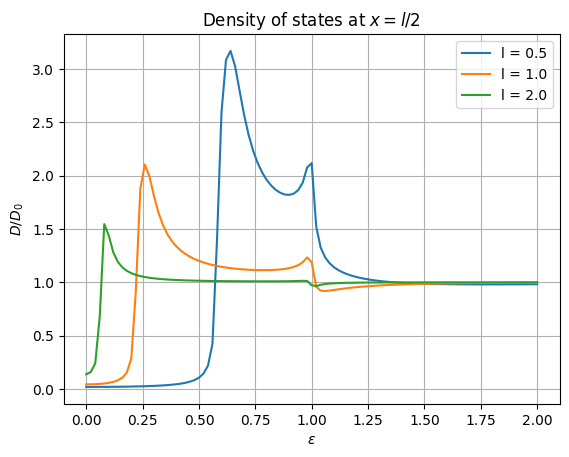

In [ ]:
# Task 2k
m = 101
eps_start = 0.0
eps_end = 2.0

fig, ax = plt.subplots()

for l in [0.5, 1.0, 2.0]:
    eps_values = np.flip(np.linspace(eps_start, eps_end, m))
    
    x = np.linspace(0, l, m)
    y = np.zeros((32, m))  
    
    DOS_middle = []  
    
    for e in eps_values:
        sol = solve_bvp(make_diff_system(e), make_bc(e, l, phi_L=0.0, phi_R=0.0), x, y)
        
        y = sol.sol(x)  
        
        v_mid = sol.sol(np.array([l/2]))[:, 0]
        gamma_i, gamma_tilde_i, _, _ = [M_transform_inverse(xi) for xi in v_to_matrices(v_mid)]
        DOS_middle.append(DOS_fun(gamma_i, gamma_tilde_i))
    
    ax.plot(np.flip(eps_values), np.flip(DOS_middle), label=f'l = {l}')

ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel(r'$D/D_0$')
ax.set_title(r'Density of states at $x = l/2$')
ax.legend()
ax.grid(True)
plt.show()

### Oppgave 2l: Strømintegrand

In [20]:

def dgreens_fun(gamma: np.ndarray, gamma_tilde: np.ndarray, omega: np.ndarray, omega_tilde: np.ndarray) -> np.ndarray:
    N = N_fun(gamma, gamma_tilde, False) 
    N_tilde = N_fun(gamma, gamma_tilde, True)

    dN = N @ (omega @ gamma_tilde + gamma @ omega_tilde) @ N
    dN_tilde = N_tilde @ (omega_tilde @ gamma + gamma_tilde @ omega) @ N_tilde

    return 2 * np.block([
        [dN, N @ omega + dN @ gamma],
        [-N_tilde @ omega_tilde - dN_tilde @ gamma_tilde, -dN_tilde]
    ])


def j_current(gamma: np.ndarray, gamma_tilde: np.ndarray, omega: np.ndarray, omega_tilde: np.ndarray) -> float:
    I = np.eye(2) # identity matrix
    M_0 = np.zeros((2, 2)) # zero matrix

    rho_hat = np.block([[I, M_0], [M_0, -I]])
    g_hat = greens_fun(gamma, gamma_tilde)
    dg_hat = dgreens_fun(gamma, gamma_tilde, omega, omega_tilde)

    return np.real(np.trace(rho_hat @ (g_hat @ dg_hat - dg_hat @ g_hat)))

#### Plot av strømintegranden $j(x, \epsilon)$

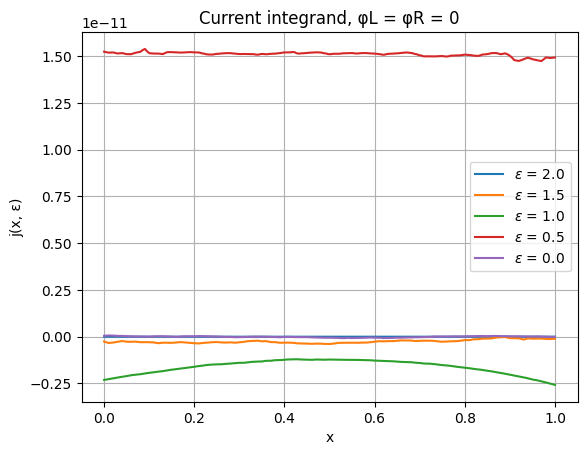

In [22]:
fig, ax = plt.subplots()

eps_plot = [2.0, 1.5, 1.0, 0.5, 0.0]
eps = np.flip(np.union1d(np.linspace(0.0, 2.0, m), eps_plot))

x = np.linspace(0, 1.0, m)
y = np.zeros((32, m))
l = 1.0

results = {}
for e in eps:
    sol = solve_bvp(make_diff_system(e), make_bc(e, l, phi_L=0.0, phi_R=0.0), x, y)
    y = sol.sol(x)
    results[e] = sol

x_plot = np.linspace(0, 1.0, 200)
for e in eps_plot:
    v_plot = results[e].sol(x_plot)
    
    j_vals = []
    for i in range(len(x_plot)):
        v_i = v_plot[:, i]
        gamma_i, gamma_tilde_i, omega_i, omega_tilde_i = [M_transform_inverse(xi) for xi in v_to_matrices(v_i)]
        j_vals.append(j_current(gamma_i, gamma_tilde_i, omega_i, omega_tilde_i))
    
    ax.plot(x_plot, j_vals, label=rf'$\epsilon$ = {e}')

ax.set_xlabel('x')
ax.set_ylabel('j(x, ε)')
ax.set_title('Current integrand, φL = φR = 0')
ax.legend()
ax.grid(True)
plt.show()